# End-to-End Sentiment + Topic Modeling (CIA-3)

This notebook:

- Loads **YouTube comments CSVs** and **video transcripts (TXT)** for **West / Middle East / India**
- Creates **VADER** sentiment scores and **pseudo-labels** (Positive / Neutral / Negative)
- Trains and evaluates **Naive Bayes (NB)**, **Random Forest (RF)**, **SVM** with **Stratified K-Fold cross-validation**
- Runs **LDA topic modeling** separately for each region and for **(a) transcripts** and **(b) comments**
- Produces **word clouds** for each region/source (and optional per-topic clouds)

> Tip: If you already have *ground-truth labels*, replace the VADER pseudo-labeling step with your labels and keep the rest unchanged.


## 0. Setup

If any import fails, install with:

```bash
pip install -U pandas numpy scikit-learn nltk vaderSentiment gensim wordcloud matplotlib
```


In [1]:

import os, re, json, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# NLP + ML
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# VADER
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Topic modeling
from sklearn.decomposition import LatentDirichletAllocation

# Wordcloud
from wordcloud import WordCloud

# NLTK stopwords (optional; falls back if unavailable)
try:
    import nltk
    from nltk.corpus import stopwords
    nltk.download("stopwords", quiet=True)
    STOPWORDS = set(stopwords.words("english"))
except Exception:
    STOPWORDS = set()


## 1. File paths (edit if needed)

These match your uploaded files. If you move files, update paths below.


In [2]:
DATA_PATHS = {
  "transcripts": {
    "WEST": {
      "CNN": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\CNN_transcript.txt",
      "BBC": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\BBC_transcript.txt",
      "FOX": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\Fox_transcript.txt"
    },
    "MIDDLE_EAST": {
      "AJ1": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\AJ1_transcript.txt",
      "AJ2": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\AJ2_transcript.txt",
      "AJ3": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\AJ3_transcript.txt"
    },
    "INDIA": {
      "CNBC": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\CNBC_transcript.txt",
      "WION": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\WION_transcript.txt",
      "REPUBLIC": "C:\\Text_Analytics\\CIA3\\data\\input_raw\\transcripts\\Rep_transcript.txt"
    }
  },
  "comments": {
    "WEST": {
      "CNN": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\CNN_US_&_Israel_launch_attack_on_Iran.csv",
      "BBC": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\BBC_Irans_Supreme_Leader_Khamenei_confirmed_killed_in_airstrikes_BBC_News.csv",
      "FOX": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\Fox_BREAKING_US_and_Israel_strike_Iran.csv"
    },
    "MIDDLE_EAST": {
      "AJ1": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\AJ1_Israel_launches_attack_on_Iran,_explosions_in_downtown_Tehran.csv",
      "AJ2": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\AJ2_What_dangers_does_the_US_and_Israel_attack_on_Iran_pose_Inside_Story.csv",
      "AJ3": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\AJ3_Iran_confirms_Supreme_Leader_Ali_Khamenei_dead_after_US-Israeli_attacks.csv"
    },
    "INDIA": {
      "CNBC": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\CNBC_Middle_East_Military_Escalation_Iran_Strikes_US_Bases_in_Qatar_&_Bahrain_Iran_Vs_US_War_N18G.csv",
      "WION": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\WION_Israel-Iran_War_Iran_Begins_Counter_Strike,_Launches_Missiles_Towards_Israel_GRAVITAS_HIGHLIGHT.csv",
      "REPUBLIC": "C:\\Text_Analytics\\CIA3\data\\input_raw\\comments\\Rep_Can_Iran_Defeat_US_&_Israel_In_This_war_Will_Putin_Back_Tehran_The_GD_Bakshi_Podcast.csv"
    }
  }
}

## 2. Load data (comments + transcripts)

We will:
- read each CSV
- automatically detect the most likely **comment text column**
- read each transcript TXT


In [3]:

def read_text_file(path: str) -> str:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    return path.read_text(encoding="utf-8", errors="ignore")

def detect_text_column(df: pd.DataFrame) -> str:
    # Heuristics to find the *actual* comment text column.
    # Many YouTube exports contain both `comment_id` and `text`.
    # We prioritize `text`/`content` columns and explicitly avoid ID columns.
    cols = list(df.columns)
    lower_map = {c: str(c).lower() for c in cols}

    # 1) Strong preference for exact/common names
    preferred_exact = ["text", "comment_text", "content", "message", "body"]
    for target in preferred_exact:
        for c in cols:
            if lower_map[c] == target:
                return c

    # 2) Candidate columns: likely text columns (contain text/content/message/body/comment)
    #    but exclude ID-like fields.
    bad_substrings = ["_id", " id", "id_", "video_id", "channel_id", "comment_id", "parent_id", "author_channel_id"]
    good_substrings = ["text", "content", "message", "body", "comment"]

    candidates = []
    for c in cols:
        cl = lower_map[c]
        if any(g in cl for g in good_substrings) and not any(b in cl for b in bad_substrings):
            candidates.append(c)

    # 3) If still none, fall back to object columns (strings)
    if not candidates:
        candidates = [c for c in cols if df[c].dtype == "object"]
        if not candidates:
            raise ValueError("No object/text columns found in CSV.")

    # 4) Choose the column that looks most like natural language:
    #    maximize average *word count* (IDs are long but have very few spaces).
    def avg_word_count(series: pd.Series) -> float:
        s = series.astype(str)
        return s.str.split().map(len).mean()

    scores = {c: avg_word_count(df[c]) for c in candidates}
    return max(scores, key=scores.get)

def load_comments(paths_by_region: dict) -> pd.DataFrame:
    rows = []
    for region, channels in paths_by_region.items():
        for channel, path in channels.items():
            df = pd.read_csv(path, encoding="utf-8", engine="python", on_bad_lines="skip")
            text_col = detect_text_column(df)
            temp = pd.DataFrame({
                "region": region,
                "source": channel,
                "source_type": "comment",
                "text": df[text_col].astype(str)
            })
            # keep optional metadata if present
            for meta in ["like", "likes", "reply", "replies", "published", "time", "date"]:
                meta_cols = [c for c in df.columns if meta in str(c).lower()]
                if meta_cols:
                    temp[meta] = df[meta_cols[0]]
            rows.append(temp)
    out = pd.concat(rows, ignore_index=True)
    return out

def load_transcripts(paths_by_region: dict) -> pd.DataFrame:
    rows = []
    for region, channels in paths_by_region.items():
        for channel, path in channels.items():
            txt = read_text_file(path)
            rows.append({
                "region": region,
                "source": channel,
                "source_type": "transcript",
                "text": txt
            })
    return pd.DataFrame(rows)

comments_df = load_comments(DATA_PATHS["comments"])
transcripts_df = load_transcripts(DATA_PATHS["transcripts"])

print("Comments:", comments_df.shape, " | Transcripts:", transcripts_df.shape)
comments_df.head(3)


Comments: (42121, 8)  | Transcripts: (9, 4)


,region,source,source_type,text,like,reply,published,date
0,WEST,CNN,comment,US and Israel attack Iran as Tehran retaliates...,15886.0,False,2026-02-28T11:15:31Z,2026-02-28T11:17:49Z
1,WEST,CNN,comment,Qatar go tonhell,15886.0,False,2026-02-28T11:15:31Z,2026-03-04T16:36:23Z
2,WEST,CNN,comment,Trump Mentally sick,15886.0,False,2026-02-28T11:15:31Z,2026-03-04T16:35:54Z


## 3. Clean text

We normalize text (URLs, extra spaces) and remove empty rows.


In [4]:

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")
NONPRINT_RE = re.compile(r"[^\x00-\x7F]+")

def clean_text(s: str) -> str:
    s = str(s)
    s = URL_RE.sub(" ", s)
    s = MENTION_RE.sub(" ", s)
    s = HASHTAG_RE.sub(" ", s)
    s = NONPRINT_RE.sub(" ", s)
    s = s.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

comments_df["text_clean"] = comments_df["text"].map(clean_text)
transcripts_df["text_clean"] = transcripts_df["text"].map(clean_text)

comments_df = comments_df[comments_df["text_clean"].str.len() > 0].copy()
transcripts_df = transcripts_df[transcripts_df["text_clean"].str.len() > 0].copy()

print("After cleaning - Comments:", comments_df.shape, " | Transcripts:", transcripts_df.shape)


After cleaning - Comments: (41183, 9)  | Transcripts: (9, 5)


## 4. VADER sentiment scoring + pseudo-labels

We compute VADER compound score and map to labels:

- **Positive**: compound >= 0.05  
- **Negative**: compound <= -0.05  
- **Neutral** otherwise

These pseudo-labels let us train NB/RF/SVM with cross-validation.


In [5]:

analyzer = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
    return analyzer.polarity_scores(text)["compound"]

def vader_label(comp: float, pos_th=0.05, neg_th=-0.05) -> str:
    if comp >= pos_th:
        return "positive"
    if comp <= neg_th:
        return "negative"
    return "neutral"

# Comments
comments_df["vader_compound"] = comments_df["text_clean"].map(vader_compound)
comments_df["label"] = comments_df["vader_compound"].map(vader_label)

# Transcripts: split into sentences for sentiment (better granularity)
SENT_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")
def transcript_to_sentences(txt: str, min_len=25):
    sents = [s.strip() for s in SENT_SPLIT_RE.split(txt) if s.strip()]
    sents = [s for s in sents if len(s) >= min_len]
    return sents

transcript_sent_rows = []
for _, row in transcripts_df.iterrows():
    for sent in transcript_to_sentences(row["text_clean"]):
        comp = vader_compound(sent)
        transcript_sent_rows.append({
            "region": row["region"],
            "source": row["source"],
            "source_type": "transcript_sentence",
            "text_clean": sent,
            "vader_compound": comp,
            "label": vader_label(comp),
        })
transcript_sents_df = pd.DataFrame(transcript_sent_rows)

print("Transcript sentences:", transcript_sents_df.shape)
comments_df["label"].value_counts(normalize=True).rename("comments_label_share"), transcript_sents_df["label"].value_counts(normalize=True).rename("transcript_label_share")


Transcript sentences: (1078, 6)


(label
 negative    0.442003
 positive    0.288906
 neutral     0.269092
 Name: comments_label_share, dtype: float64,
 label
 negative    0.400742
 neutral     0.333952
 positive    0.265306
 Name: transcript_label_share, dtype: float64)

## 5. Balance the training data (recommended)

Your outlets have very different comment volumes. For fair comparison and stable ML training,
we sample the same number of items per **region + source_type**.

Adjust `N_PER_GROUP` if you want larger/smaller.


In [6]:

N_PER_GROUP = 5000  # per (region, source_type); will take min if fewer available
RANDOM_STATE = 42

def balanced_sample(df: pd.DataFrame, group_cols, n_per_group: int, text_col="text_clean"):
    parts = []
    for key, g in df.groupby(group_cols):
        g = g[g[text_col].str.len() > 0].copy()
        take = min(n_per_group, len(g))
        parts.append(g.sample(take, random_state=RANDOM_STATE))
    return pd.concat(parts, ignore_index=True)

# Build one combined dataset for supervised training from:
# - all comments
# - transcript sentences
train_df = pd.concat([
    comments_df[["region","source","source_type","text_clean","label"]],
    transcript_sents_df[["region","source","source_type","text_clean","label"]],
], ignore_index=True)

train_bal = balanced_sample(train_df, ["region","source_type"], N_PER_GROUP)
print("Train dataset size (balanced):", train_bal.shape)
train_bal["label"].value_counts()


Train dataset size (balanced): (12959, 5)


label
negative    5622
positive    3850
neutral     3487
Name: count, dtype: int64

## 6. Train + Evaluate NB, RF, SVM with Stratified K-Fold CV

We train on TF-IDF features.

Metrics reported:
- accuracy
- macro F1
- macro precision
- macro recall

You can change `N_SPLITS` (folds) per your faculty requirement.


In [7]:

X = train_bal["text_clean"].values
y = train_bal["label"].values

N_SPLITS = 5  # change to 10 if you want 10-fold CV

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}

pipelines = {
    "MultinomialNB": Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ("clf", MultinomialNB())
    ]),
    "RandomForest": Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ("clf", RandomForestClassifier(
            n_estimators=400,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "LinearSVM": Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ("clf", LinearSVC())
    ]),
}

results = []
for name, pipe in pipelines.items():
    cv_res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    row = {"model": name}
    for k, v in cv_res.items():
        if k.startswith("test_"):
            row[k.replace("test_","")] = float(np.mean(v))
            row[k.replace("test_","")+"_std"] = float(np.std(v))
    results.append(row)

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df


,model,accuracy,accuracy_std,f1_macro,f1_macro_std,precision_macro,precision_macro_std,recall_macro,recall_macro_std
2,LinearSVM,0.772976,0.005399,0.767628,0.004546,0.767724,0.005231,0.770212,0.004339
1,RandomForest,0.767805,0.006884,0.762976,0.006620,0.767174,0.006187,0.769250,0.006119
0,MultinomialNB,0.638242,0.011581,0.591389,0.015471,0.699202,0.017315,0.585591,0.013126


## 7. Fit final models (on all balanced data) and run inference

We fit each model on `train_bal`, then predict labels for:
- full comments
- transcript sentences


In [8]:

fitted = {}
for name, pipe in pipelines.items():
    pipe.fit(train_bal["text_clean"], train_bal["label"])
    fitted[name] = pipe

# Choose best model by macro F1 from CV
best_model_name = results_df.iloc[0]["model"]
best_model = fitted[best_model_name]
print("Best model:", best_model_name)

comments_df["pred_label"] = best_model.predict(comments_df["text_clean"])
transcript_sents_df["pred_label"] = best_model.predict(transcript_sents_df["text_clean"])

comments_df[["region","source","pred_label"]].head()


Best model: LinearSVM


,region,source,pred_label
0,WEST,CNN,negative
1,WEST,CNN,neutral
2,WEST,CNN,negative
3,WEST,CNN,negative
4,WEST,CNN,neutral


## 8. Sentiment summaries by region and source

We report:
- VADER label distribution
- Best-model predicted label distribution


In [9]:

def label_share(df, label_col):
    return (df.groupby(["region","source"])[label_col]
              .value_counts(normalize=True)
              .rename("share")
              .reset_index()
              .pivot_table(index=["region","source"], columns=label_col, values="share", fill_value=0)
              .reset_index()
           )

print("VADER label share (comments):")
display(label_share(comments_df, "label").head(12))

print("Predicted label share (comments):")
display(label_share(comments_df, "pred_label").head(12))

print("Predicted label share (transcript sentences):")
display(label_share(transcript_sents_df, "pred_label").head(12))


VADER label share (comments):


label,region,source,negative,neutral,positive
0,INDIA,CNBC,0.518293,0.262195,0.219512
1,INDIA,REPUBLIC,0.372310,0.267575,0.360115
2,INDIA,WION,0.452830,0.327044,0.220126
3,MIDDLE_EAST,AJ1,0.458026,0.263496,0.278478
4,MIDDLE_EAST,AJ2,0.500435,0.241950,0.257615
5,MIDDLE_EAST,AJ3,0.432856,0.268800,0.298344
6,WEST,BBC,0.455637,0.262123,0.282240
7,WEST,CNN,0.458140,0.260961,0.280899
8,WEST,FOX,0.414223,0.286742,0.299035


Predicted label share (comments):


pred_label,region,source,negative,neutral,positive
0,INDIA,CNBC,0.533537,0.237805,0.228659
1,INDIA,REPUBLIC,0.366571,0.281205,0.352224
2,INDIA,WION,0.471698,0.333333,0.194969
3,MIDDLE_EAST,AJ1,0.458502,0.280143,0.261356
4,MIDDLE_EAST,AJ2,0.497824,0.259356,0.242820
5,MIDDLE_EAST,AJ3,0.421218,0.286705,0.292077
6,WEST,BBC,0.462843,0.281639,0.255517
7,WEST,CNN,0.447326,0.287573,0.265101
8,WEST,FOX,0.413040,0.309780,0.277181


Predicted label share (transcript sentences):


pred_label,region,source,negative,neutral,positive
0,INDIA,CNBC,0.262295,0.442623,0.295082
1,INDIA,REPUBLIC,0.394958,0.306723,0.298319
2,INDIA,WION,0.562500,0.125000,0.312500
3,MIDDLE_EAST,AJ1,0.444444,0.340278,0.215278
4,MIDDLE_EAST,AJ2,0.360169,0.381356,0.258475
5,MIDDLE_EAST,AJ3,0.578947,0.105263,0.315789
6,WEST,BBC,0.490909,0.303030,0.206061
7,WEST,CNN,0.244898,0.489796,0.265306
8,WEST,FOX,0.323529,0.411765,0.264706


In [23]:
# Additional filler stopwords for spoken transcripts
FILLER_STOPWORDS = {
    "uh","um","yeah","well","like","know","think","mean","actually","basically",
    "right","okay","ok","really","look","say","said","going","get","got","let",
    "one","two","also","now","today","thing","things","people","lot","way",
    "kind","sort","something","anything","everything","maybe","even","still", 
    "report","reported","reports","according",
    "says","say","told","telling","statement",
    "minister","official","government",
    "president","leader","state","country"
}

CUSTOM_STOPWORDS = set(STOPWORDS).union(FILLER_STOPWORDS)
CUSTOM_STOPWORDS_LIST = sorted(CUSTOM_STOPWORDS)

## 9. LDA topic modeling by region and source (comments vs transcripts)

We do LDA separately for each **region** and for each **source_type_group**:
- comments
- transcripts (all transcript sentences combined per source, or optionally full transcript text)

We:
- vectorize with CountVectorizer
- fit LDA
- print top words per topic
- create word cloud per region/source_type_group



=== LDA Topics: WEST | comments ===
Topic 01: trump, iran, nuclear, lol, go, obama, money, would, time, oil, weapons, stop
Topic 02: war, iran, wars, us, israel, america, first, trump, new, would, attack, congress
Topic 03: epstein, files, trump, news, war, bbc, release, school, distraction, years, girls, distract
Topic 04: iran, israel, usa, us, world, iranian, killed, america, terrorist, go, countries, free
Topic 05: trump, war, us, israel, american, russia, wars, china, want, netanyahu, americans, donald
Topic 06: peace, iran, trump, god, regime, good, america, change, evil, iranian, war, world


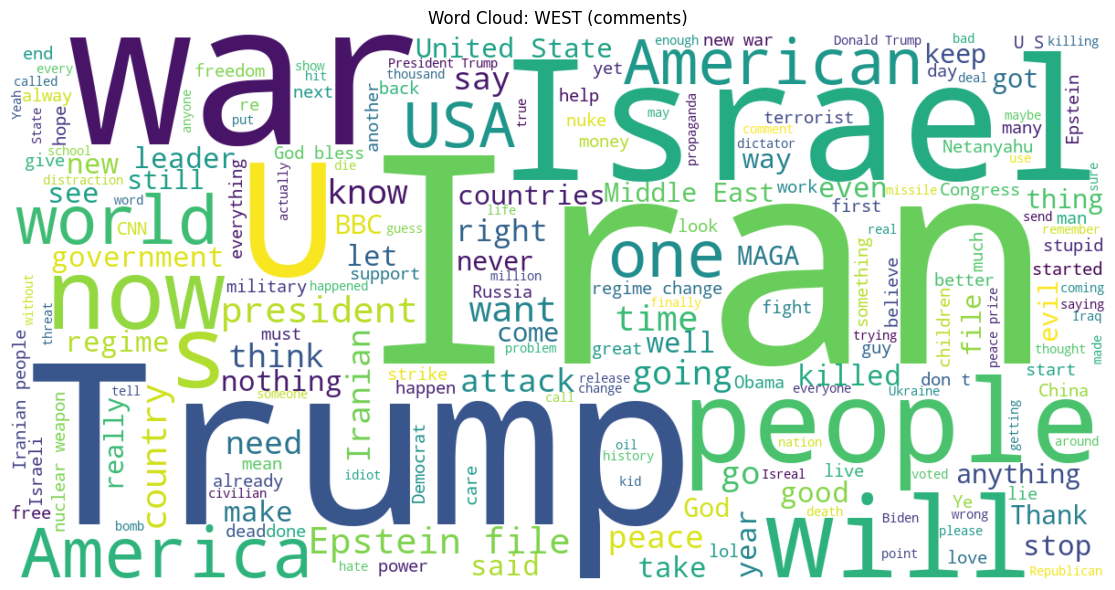


=== LDA Topics: WEST | transcripts ===
Topic 01: war, iran, take, day, including, far, live, political, gulf, across, long, iranians
Topic 02: iran, us, strike, israel, white, house, strikes, launched, bahrain, action, tehran, qatar
Topic 03: region, states, united, military, many, bases, troops, directly, days, would, tonight, gulf
Topic 04: iranian, middle, regime, east, operation, american, could, iranians, killed, military, many, israeli
Topic 05: israel, iran, regime, missile, us, missiles, across, change, israelis, air, ballistic, defense
Topic 06: trump, donald, hit, around, dubai, region, back, iranian, see, moment, killed, heard


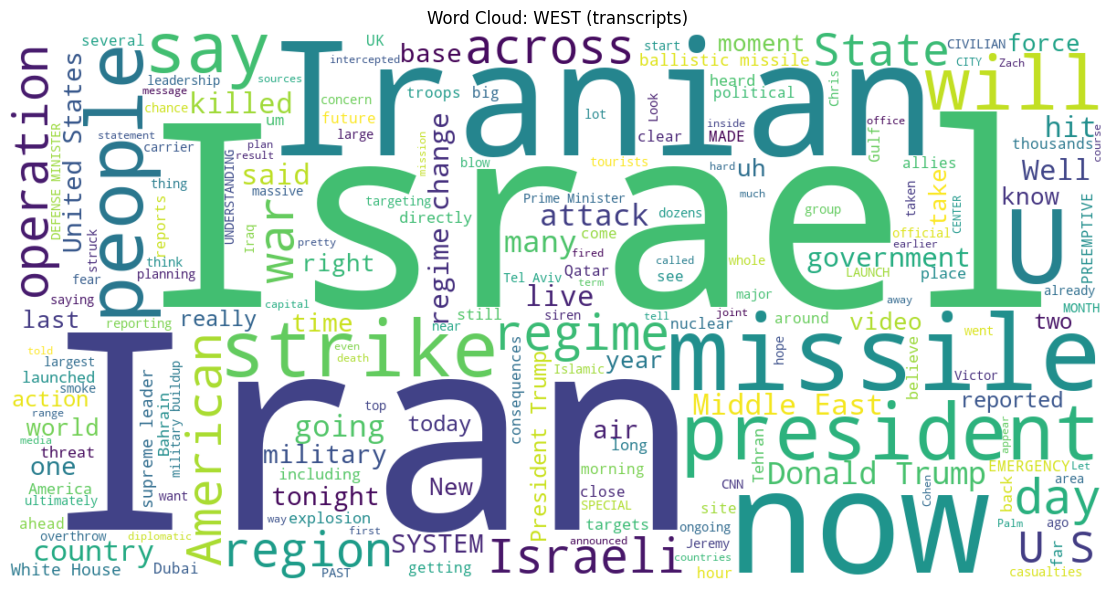


=== LDA Topics: MIDDLE_EAST | comments ===
Topic 01: israel, war, news, us, good, iran, usa, korea, died, north, sad, world
Topic 02: iran, israel, us, usa, world, attack, war, time, nuclear, china, russia, middle
Topic 03: peace, world, nuclear, killed, children, iranian, us, killing, boom, power, would, evil
Topic 04: iran, regime, iranian, attack, us, israel, iranians, would, go, years, freedom, see
Topic 05: iran, allah, god, may, inna, israel, wa, bless, khamenei, us, dead, free
Topic 06: trump, israel, america, war, iran, epstein, al, netanyahu, countries, jazeera, files, us


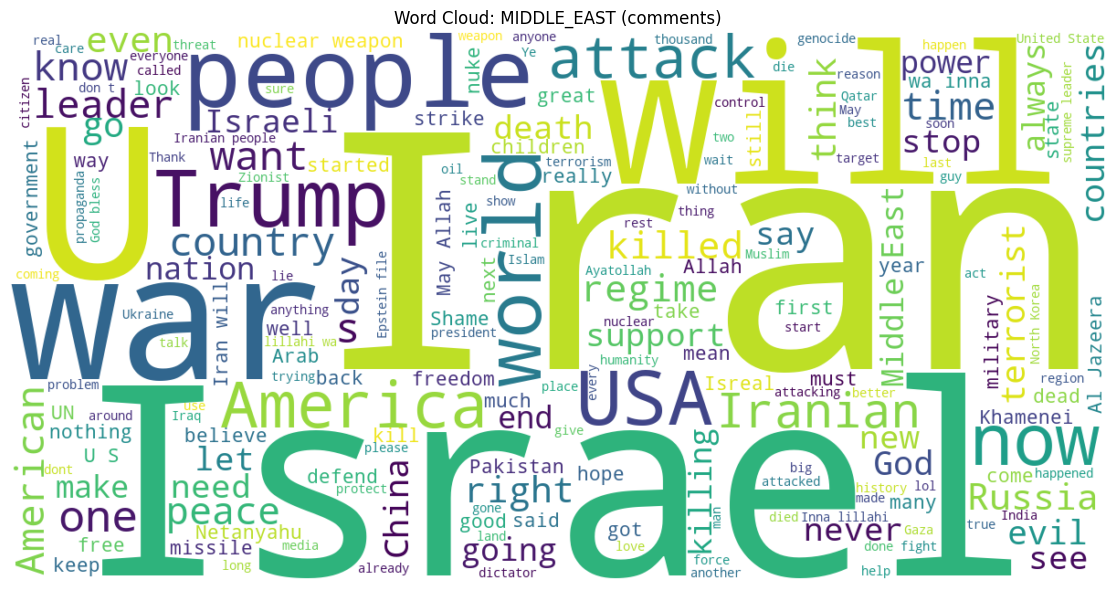


=== LDA Topics: MIDDLE_EAST | transcripts ===
Topic 01: states, united, war, nuclear, us, daniel, american, foreign, negotiations, moment, wars, problem
Topic 02: israel, iran, strikes, wants, public, hezbollah, day, saw, month, operation, israeli, far
Topic 03: trump, donald, us, days, israeli, iranian, killed, strikes, james, attacks, heard, started
Topic 04: israeli, israel, america, strike, coming, army, preemptive, ago, us, question, attack, days
Topic 05: iranian, supreme, regime, change, want, inside, yet, diplomacy, council, story, bring, fact
Topic 06: us, iran, would, region, israel, military, time, world, go, alan, buildup, talks


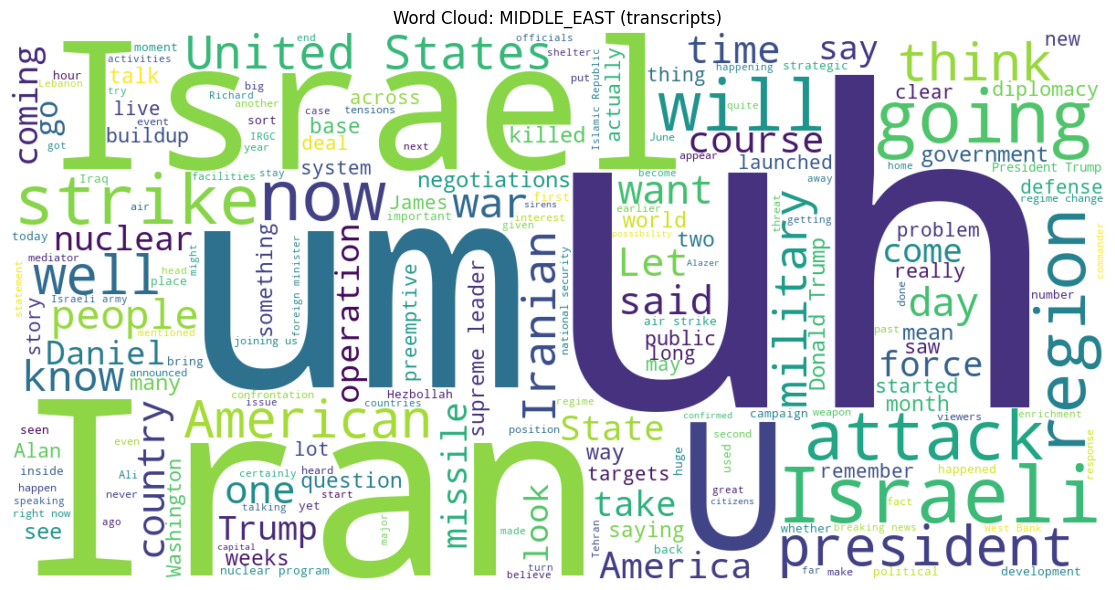


=== LDA Topics: INDIA | comments ===
Topic 01: gen, anchor, man, pakistan, old, keep, stupid, need, please, irritating, news, iran
Topic 02: iran, good, regime, israel, iranian, world, god, trump, america, job, send, putin
Topic 03: iran, war, 90, billion, us, go, die, million, lol, expert, win, population
Topic 04: iran, israel, russia, usa, america, war, attack, us, china, countries, isreal, middle
Topic 05: india, israel, usa, trump, iran, modi, indian, world, epstein, real, guy, files
Topic 06: bakshi, general, analysis, mr, great, sir, excellent, interview, thank, gd, many, true


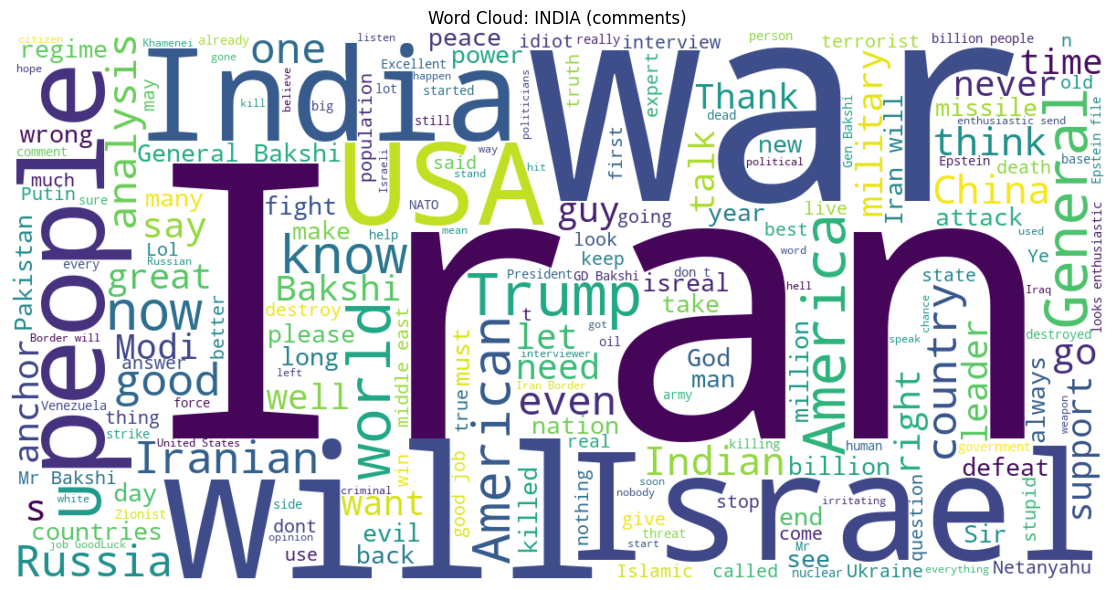


=== LDA Topics: INDIA | transcripts ===
Topic 01: israel, us, states, war, united, fire, iran, want, world, protesters, gone, pakistan
Topic 02: iran, israel, day, last, america, days, go, china, situation, might, towards, would
Topic 03: missiles, etc, american, hit, americans, gulf, stop, chinese, hypersonic, could, ballistic, intelligence
Topic 04: iran, prime, fact, pakistan, netanyahu, india, would, back, trump, strikes, modi, 30
Topic 05: iranian, would, time, trump, america, missile, american, attack, israeli, donald, regime, hit
Topic 06: see, already, battle, fight, prize, nobel, middle, east, take, fact, matter, able


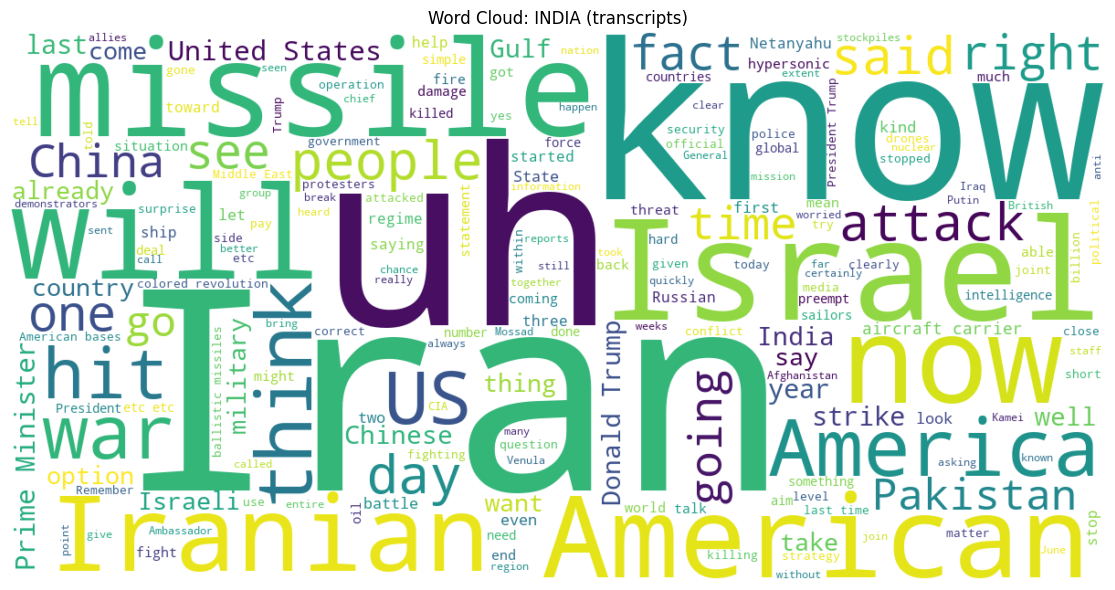

In [24]:

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def fit_lda(docs, n_topics=6, max_features=4000):
    vectorizer = CountVectorizer(
    stop_words=CUSTOM_STOPWORDS_LIST,
    lowercase=True,
    max_df=0.9,
    min_df=5,
    max_features=5000
    )
    X = vectorizer.fit_transform(docs)
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=RANDOM_STATE,
        learning_method="batch"
    )
    lda.fit(X)
    return lda, vectorizer, X

def top_words_per_topic(lda, feature_names, n_top_words=12):
    topics = []
    for topic_idx, topic in enumerate(lda.components_):
        top_idx = topic.argsort()[:-n_top_words-1:-1]
        words = [feature_names[i] for i in top_idx]
        topics.append((topic_idx, words))
    return topics

def make_wordcloud(text, title, outpath):
    wc = WordCloud(width=1200, height=600, background_color="white").generate(text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()

def region_docs_comments(region):
    df = comments_df[comments_df["region"] == region].copy()
    return df["text_clean"].tolist()

def region_docs_transcripts(region):
    df = transcript_sents_df[transcript_sents_df["region"] == region].copy()
    return df["text_clean"].tolist()

def run_lda_for_region(region, docs, label):
    if len(docs) < 200:
        print(f"[WARN] Too few docs for {region}-{label}: {len(docs)}")
        return
    lda, vec, X = fit_lda(docs, n_topics=6, max_features=5000)
    feats = vec.get_feature_names_out()
    topics = top_words_per_topic(lda, feats, n_top_words=12)

    print(f"\n=== LDA Topics: {region} | {label} ===")
    for idx, words in topics:
        print(f"Topic {idx+1:02d}: " + ", ".join(words))

    # Wordcloud from ALL docs combined (good for region-wide themes)
    joined = " ".join(docs)
    outpath = OUTPUT_DIR / f"wordcloud_{region.lower()}_{label}.png"
    make_wordcloud(joined, f"Word Cloud: {region} ({label})", outpath)

for region in ["WEST","MIDDLE_EAST","INDIA"]:
    run_lda_for_region(region, region_docs_comments(region), "comments")
    run_lda_for_region(region, region_docs_transcripts(region), "transcripts")


## 10. Optional: word clouds per source outlet

If you want to show CNN vs BBC vs FOX separately (etc.), run this cell.


In [ ]:

def run_wordclouds_per_source(df, text_col, label):
    for (region, source), g in df.groupby(["region","source"]):
        joined = " ".join(g[text_col].tolist())
        if len(joined) < 2000:
            continue
        outpath = OUTPUT_DIR / f"wordcloud_{label}_{region.lower()}_{source.lower()}.png"
        make_wordcloud(joined, f"Word Cloud: {source} ({region}) [{label}]", outpath)

# Comments outlet-level clouds
run_wordclouds_per_source(comments_df, "text_clean", "comments")

# Transcript sentence outlet-level clouds
run_wordclouds_per_source(transcript_sents_df, "text_clean", "transcripts")


## 11. Export key tables (optional)

Saves:
- model CV results
- sentiment shares


In [ ]:

results_df.to_csv(OUTPUT_DIR / "cv_results_models.csv", index=False)

label_share(comments_df, "pred_label").to_csv(OUTPUT_DIR / "sentiment_share_comments_pred.csv", index=False)
label_share(transcript_sents_df, "pred_label").to_csv(OUTPUT_DIR / "sentiment_share_transcripts_pred.csv", index=False)

print("Saved to:", OUTPUT_DIR.resolve())
